Final Output:
[[0.016]
 [0.979]
 [0.975]
 [0.028]]


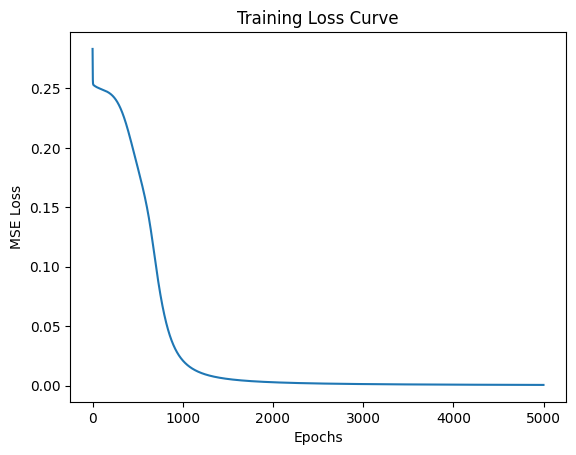

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# Initialize weights and biases concisely
W1, b1 = np.random.randn(2, 4), np.zeros((1, 4))
W2, b2 = np.random.randn(4, 1), np.zeros((1, 1))

# Helper math functions
sig = lambda x: 1 / (1 + np.exp(-x))
sig_d = lambda x: x * (1 - x)

losses = []

for _ in range(5000):
    # Forward Pass
    a1 = sig(np.dot(X, W1) + b1)
    output = sig(np.dot(a1, W2) + b2)
    
    # Track the exact same loss curve
    losses.append(np.mean((y - output)**2))
    
    # Backward Pass
    d_output = (output - y) * sig_d(output)
    d_hidden = np.dot(d_output, W2.T) * sig_d(a1)
    
    # Weight Updates (Learning Rate = 0.5)
    W2 -= 0.5 * np.dot(a1.T, d_output)
    b2 -= 0.5 * np.sum(d_output, axis=0, keepdims=True)
    W1 -= 0.5 * np.dot(X.T, d_hidden)
    b1 -= 0.5 * np.sum(d_hidden, axis=0, keepdims=True)

# Generate the exact original outputs
print("Final Output:")
print(output.round(3))

plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()